In [1]:
# % pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset  
df = pd.read_csv("train.csv")
df
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
print("Shape:",df.shape)
print("\nColumns\n:", df.columns)
print("\nData Types;\n",df.dtypes)

Shape: (9800, 18)

Columns
: Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

Data Types;
 Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object


In [4]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

In [5]:
# Postal Code ke nulls drop 
df = df.dropna(subset=['Postal Code'])

# Order Date aur Ship Date ko proper date format mein convert 
df['Order Date'] = pd.to_datetime(df['Order Date'],format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'],format='%d/%m/%Y')

# Verify 
print("Null values ab:", df.isnull().sum().sum())
print("Shape ab:", df.shape)
print("Order Date type:", df['Order Date'].dtype)

Null values ab: 0
Shape ab: (9789, 18)
Order Date type: datetime64[ns]


In [6]:
# Region wise total sales
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales = region_sales.sort_values('Sales',ascending = False)
print(region_sales)

    Region        Sales
3     West  710219.6845
1     East  660589.3560
0  Central  492646.9132
2    South  389151.4590


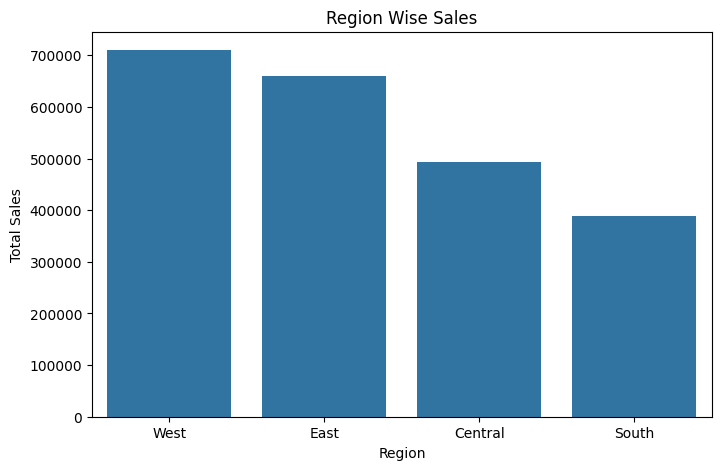

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(x='Region',y='Sales',data=region_sales)
plt.title("Region Wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

In [8]:
# Category wise total sales
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values('Sales',ascending=False)
category_sales

,Category,Sales
2,Technology,825856.1130
0,Furniture,723538.4757
1,Office Supplies,703212.8240


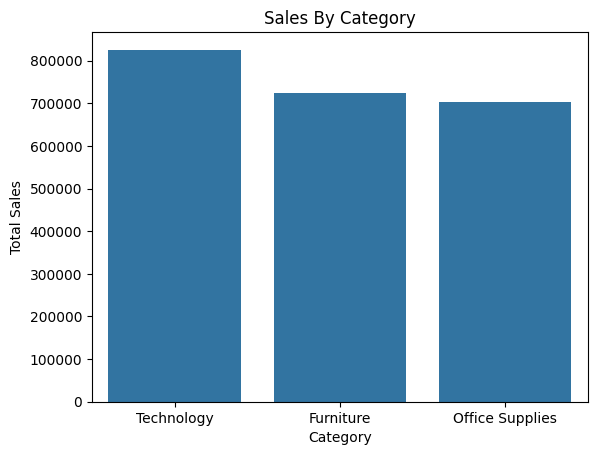

In [9]:
plt.Figure(figsize=(8,5))
sns.barplot(x='Category',y='Sales',data=category_sales)
plt.title("Sales By Category")
plt.xlabel('Category')
plt.ylabel("Total Sales")
plt.show()

In [10]:
df["Year"] = df["Order Date"].dt.year
df.Year

0       2017
1       2017
2       2017
3       2016
4       2016
        ... 
9795    2017
9796    2016
9797    2016
9798    2016
9799    2016
Name: Year, Length: 9789, dtype: int32

In [11]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
print(yearly_sales)

   Year        Sales
0  2015  479856.2081
1  2016  454315.9054
2  2017  597225.4900
3  2018  721209.8092


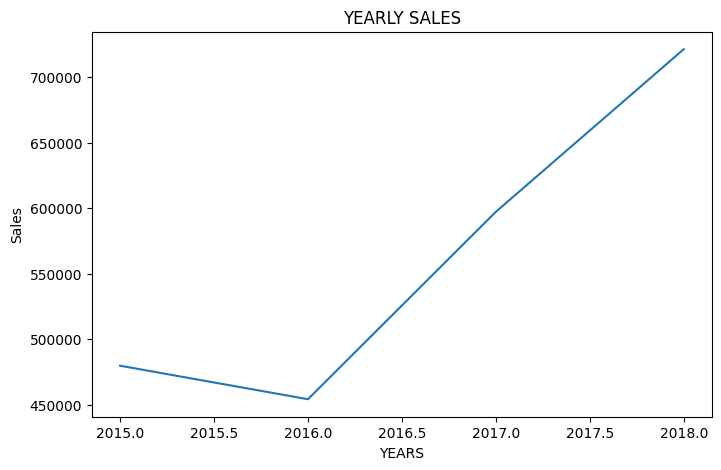

In [12]:
plt.figure(figsize=(8,5))
plt.title("YEARLY SALES")
sns.lineplot(x='Year',y='Sales',data=yearly_sales)
plt.xlabel("YEARS")
plt.ylabel("Sales")
plt.show()

In [13]:
# Reference date banao
import datetime
reference_date = df['Order Date'].max()+ datetime.timedelta(days=1)
reference_date

Timestamp('2018-12-31 00:00:00')

In [14]:
# RFM calculation
rfm = df.groupby('Customer Name').agg(
    recency = ('Order Date',lambda x : (reference_date - x.max()).days),
    frequency = ('Order ID','count'),
    monetary = ('Sales','sum')

).reset_index()
rfm

,Customer Name,recency,frequency,monetary
0,Aaron Bergman,416,6,886.156
1,Aaron Hawkins,13,11,1744.700
2,Aaron Smayling,89,10,3050.692
3,Adam Bellavance,55,18,7755.620
4,Adam Hart,35,20,3250.337
...,...,...,...,...
788,Xylona Preis,44,28,2374.658
789,Yana Sorensen,10,12,6720.444
790,Yoseph Carroll,5,8,5454.350
791,Zuschuss Carroll,55,31,8025.707


In [15]:
# Scoring 1-5
rfm['R_Score'] = pd.qcut(rfm['recency'],5,labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['frequency'],5,labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['monetary'],5,labels=[1,2,3,4,5])

# total rfm score
rfm['RFM_Score'] = rfm['R_Score'].astype(int)+rfm['F_Score'].astype(int)+rfm['M_Score'].astype(int)
rfm

,Customer Name,recency,frequency,monetary,R_Score,F_Score,M_Score,RFM_Score
0,Aaron Bergman,416,6,886.156,1,1,1,3
1,Aaron Hawkins,13,11,1744.700,5,3,3,11
2,Aaron Smayling,89,10,3050.692,3,2,4,9
3,Adam Bellavance,55,18,7755.620,4,5,5,14
4,Adam Hart,35,20,3250.337,4,5,4,13
...,...,...,...,...,...,...,...,...
788,Xylona Preis,44,28,2374.658,4,5,3,12
789,Yana Sorensen,10,12,6720.444,5,3,5,13
790,Yoseph Carroll,5,8,5454.350,5,2,5,12
791,Zuschuss Carroll,55,31,8025.707,4,5,5,14


In [16]:
def segment(score):
    if score >= 13:
        return 'Champion'
    elif score >= 10:
        return 'Loyal'
    elif score >= 7:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)
print(rfm['Segment'].value_counts())

Segment
Loyal       239
At Risk     219
Lost        211
Champion    124
Name: count, dtype: int64


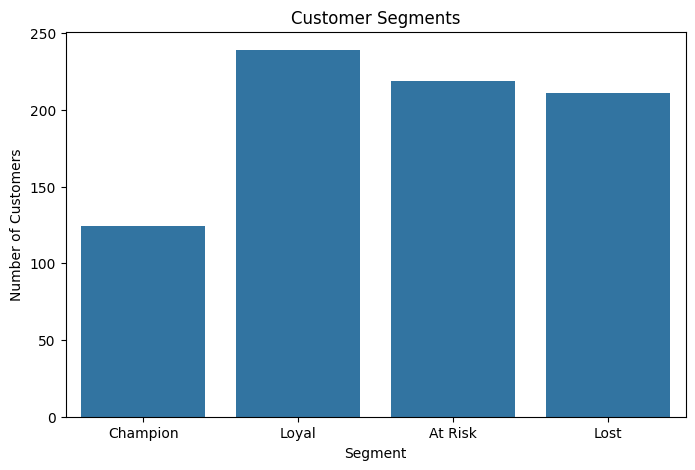

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x='Segment', data=rfm, 
              order=['Champion', 'Loyal', 'At Risk', 'Lost'])
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

In [18]:
from pandasql import sqldf

# shortcut bana lo
pysql = lambda q: sqldf(q, globals())
pysql

<function __main__.<lambda>(q)>

In [19]:
df.columns = df.columns.str.replace(' ', '_')
print(df.columns.tolist())
# print(df.columns.tolist())

['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name', 'Sales', 'Year']


In [20]:
query = """
SELECT Customer_Name,
       ROUND(SUM(Sales), 2) as Total_Sales,
       COUNT(Order_ID) as Total_Orders
FROM df
GROUP BY Customer_Name
ORDER BY Total_Sales DESC
LIMIT 10
"""

result = pysql(query)
print(result)

        Customer_Name  Total_Sales  Total_Orders
0         Sean Miller     25043.05            15
1        Tamara Chand     19052.22            12
2        Raymond Buch     15117.34            18
3        Tom Ashbrook     14595.62            10
4       Adrian Barton     14473.57            20
5        Ken Lonsdale     14175.23            29
6        Sanjit Chand     14142.33            22
7        Hunter Lopez     12873.30            11
8        Sanjit Engle     12209.44            19
9  Christopher Conant     12129.07            11


In [21]:
query2 = """
SELECT Region,
       Round(SUM(Sales),2)as Total_Sales,
       COUNT(ORDER_ID) as Total_Orders
FROM df
GROUP BY Region
ORDER BY Total_Sales DESC
"""
result2 = pysql(query2)
print(result2)

    Region  Total_Sales  Total_Orders
0     West    710219.68          3140
1     East    660589.36          2774
2  Central    492646.91          2277
3    South    389151.46          1598


In [22]:
query3 = """ 
SELECT Category,
       Round(SUM(Sales),2) as Total_Sales,
       COUNT(ORDER_ID)as Total_Orders
    FROM df
    GROUP BY Category
    ORDER BY Total_Sales DESC
    """
result3 = pysql(query3)
print(result3)

          Category  Total_Sales  Total_Orders
0       Technology    825856.11          1810
1        Furniture    723538.48          2076
2  Office Supplies    703212.82          5903


In [23]:
df.to_csv('superstore_clean.csv',index=False)
rfm.to_csv('rfm_data.csv',index=False)
print("file saved")

file saved


In [24]:
print(rfm['Segment'].value_counts())


Segment
Loyal       239
At Risk     219
Lost        211
Champion    124
Name: count, dtype: int64


In [25]:
rfm.to_csv('rfm_data.csv', index=False)
print(rfm.columns.tolist())

['Customer Name', 'recency', 'frequency', 'monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']


In [26]:
print(yearly_sales)

   Year        Sales
0  2015  479856.2081
1  2016  454315.9054
2  2017  597225.4900
3  2018  721209.8092


In [27]:
sales_2015 = yearly_sales[yearly_sales['Year'] == 2015]['Sales'].values[0]
sales_2018 = yearly_sales[yearly_sales['Year']==2018]['Sales'].values[0]
growth = ((sales_2018- sales_2015)/sales_2015)*100
print(f"Growth: {growth:.2f}%")


Growth: 50.30%


In [28]:
sum_sales = df['Sales'].sum()
total_orders = df['Sales'].count()



In [32]:
avg_order_value = sum_sales/ total_orders
print(f"{avg_order_value:.2f}")

230.12


In [35]:
df['avg_order_value'] = f"{avg_order_value:.2f}"
df

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Year,avg_order_value
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,230.12
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,230.12
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,230.12
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,230.12
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,230.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980,2017,230.12
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680,2016,230.12
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880,2016,230.12
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760,2016,230.12


In [37]:
df.to_csv('superstore_clean.csv',index=False)